# Лабораторна робота №2 : Асоціативні правила та кластеризація


**Мета:** Реалізувати програмно алгоритми пошуку асоціативних правил Apriori та FP-Growth, після чого реалізувати алгоритми кластеризації: K-Means, K-Medians, Hierarchical(Single, Complete, Ward) та DBSCAN. Провести детальну попередню підготовку та обробку даних обраного датасету. Дослідити результат навчання кожного алгоритму, зробити висновок про доцільність використання того чи іншого алгоритма кластеризації для задач датасету. Провести порівняльний аналіз отриманих результатів роботи.

**Датасет:** Статистика відеоігор на платформі Steam 2026 (URL: https://www.kaggle.com/datasets/fronkongames/steam-games-dataset)

## Зміст
1. [Setup](#setup)
2. [Associative-Rules](#rules)
    - [Preparations](#dtprep)
    - [Apriori](#apriori)
    - [FP-Growth](#fpgr)
3. [Clusterization](#clust)
    - [Preparations](#dtprep2)
    - [K-Means](#kmeans)
    - [K-Medians](#kmeans)
    - [Hierarchycal](#kmeans)
    - [K-Means](#kmeans)
4. [Results](#results)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import kagglehub
import os
import warnings
import time
import json

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.frequent_patterns import fpgrowth

warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
dataset = {}
path = kagglehub.dataset_download("fronkongames/steam-games-dataset")
json_path = os.path.join(path, "games.json")

with open(json_path, 'r', encoding='utf-8') as fin:
    dataset = json.load(fin)

rows = []
for app_id, game in dataset.items():
    rows.append({
        "AppID":                    app_id,
        "Name":                     game.get("name"),
        "Release date":             game.get("release_date"),
        "Peak CCU":                 game.get("peak_ccu"),
        "Price":                    game.get("price"),
        "Supported languages":      ", ".join(game.get("supported_languages", [])),
        "Windows":                  game.get("windows"),
        "Mac":                      game.get("mac"),
        "Linux":                    game.get("linux"),
        "Positive":                 game.get("positive"),
        "Negative":                 game.get("negative"),
        "Recommendations":          game.get("recommendations"),
        "Average playtime forever": game.get("average_playtime_forever"),
        "Median playtime forever":  game.get("median_playtime_forever"),
        "Categories":               ", ".join(game.get("categories", [])),
        "Genres":                   ", ".join(game.get("genres", [])),
        "Tags":                     ", ".join(str(t) for t in game.get("tags", [])),
    })

df = pd.DataFrame(rows)
df.head()

100%|██████████| 270M/270M [00:01<00:00, 166MB/s]

Extracting files...


,AppID,Name,Release date,Peak CCU,Price,Supported languages,Windows,Mac,Linux,Positive,Negative,Recommendations,Average playtime forever,Median playtime forever,Categories,Genres,Tags
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0,0.00,,True,False,False,0,0,0,0,0,,,
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0,5.24,English,True,False,False,252,3,231,8,8,"Single-player, Steam Trading Cards, Steam Clou...",Adventure,"Adventure, Visual Novel, Anime, Cute"
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0,4.99,"English, French, German, Russian",True,True,False,21,3,0,0,0,"Single-player, Family Sharing",Casual,"Casual, Card Game, Solitaire, Puzzle, Hidden O..."
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",1,8.99,Korean,True,False,False,0,0,0,0,0,"Single-player, Steam Achievements, Family Sharing","Casual, Indie, Simulation",
4,3631080,Maze Quest VR,"Apr 24, 2025",0,4.99,English,True,False,False,0,0,0,0,0,"Single-player, VR Only, Steam Leaderboards, Fa...","Action, Early Access",


In [4]:
df = df.drop(columns = ['Name'])

In [5]:
df = df.drop_duplicates()
df.shape

(122611, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122611 entries, 0 to 122610
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AppID                     122611 non-null  object 
 1   Release date              122611 non-null  object 
 2   Peak CCU                  122611 non-null  int64  
 3   Price                     122611 non-null  float64
 4   Supported languages       122611 non-null  object 
 5   Windows                   122611 non-null  bool   
 6   Mac                       122611 non-null  bool   
 7   Linux                     122611 non-null  bool   
 8   Positive                  122611 non-null  int64  
 9   Negative                  122611 non-null  int64  
 10  Recommendations           122611 non-null  int64  
 11  Average playtime forever  122611 non-null  int64  
 12  Median playtime forever   122611 non-null  int64  
 13  Categories                122611 non-null  o

In [7]:
def parse_list_field(value):
    if pd.isna(value):
        return []
    return [item.strip() for item in str(value).split(",") if item.strip()]

In [8]:
def price_bucket(price):
    if price == 0:
        return "price:Free"
    elif price < 10:
        return "price:Cheap"
    elif price < 30:
        return "price:Middle"
    else:
        return "price:Expensive"


def ccu_bucket(ccu):
    if ccu < 50:
        return "ccu:Low"
    elif ccu < 500:
        return "ccu:Medium"
    else:
        return "ccu:High"


def playtime_bucket(minutes):
    if minutes < 60:
        return "playtime:Short"
    elif minutes < 600:
        return "playtime:Medium"
    else:
        return "playtime:Long"


def rating_bucket(pos, neg):
    total = pos + neg
    if total == 0:
        return "rating:Unknown"
    ratio = pos / total
    if ratio < 0.5:
        return "rating:Low"
    elif ratio < 0.8:
        return "rating:Medium"
    else:
        return "rating:High"

In [9]:
tag_counter = Counter()

for tags in df["Tags"].dropna():
    tag_counter.update(parse_list_field(tags))

TOP_N_TAGS = 50
top_tags = set([t for t, _ in tag_counter.most_common(TOP_N_TAGS)])

In [10]:
def is_redundant_tag(tag, genres):
    return tag.lower() in [g.lower() for g in genres]

In [75]:
transactions = []
df_asc = df;
df_asc = df_asc[(df_asc["Positive"] + df_asc["Negative"]) >= MIN_REVIEWS]
MAX_TAGS_PER_GAME = 20
for _, row in df_asc.iterrows():
    items = []

    genres = parse_list_field(row["Genres"])
    for g in genres:
        items.append(f"genre:{g}")

    tags = [
    t for t in parse_list_field(row["Tags"])
    if t in top_tags and not is_redundant_tag(t, genres)][:MAX_TAGS_PER_GAME]

    for t in tags:
        items.append(f"tag:{t}")

    items.append(price_bucket(row["Price"]))
    items.append(ccu_bucket(row["Peak CCU"]))
    items.append(playtime_bucket(row["Average playtime forever"]))
    items.append(rating_bucket(row["Positive"], row["Negative"]))

    transactions.append(items)

In [76]:
item_counter = Counter()

for t in transactions:
    item_counter.update(t)

MIN_ITEM_FREQ = 500
print("Items:", len(item_counter))

valid_items = {item for item, count in item_counter.items() if count >= MIN_ITEM_FREQ}

transactions = [
    [item for item in t if item in valid_items]
    for t in transactions
]

print("Remaining unique items:", len(valid_items))

Items: 90
Remaining unique items: 57


In [77]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(df_encoded.shape)

(7206, 57)


In [78]:
frequent_itemsets = apriori(
    df_encoded,
    min_support=0.05,
    use_colnames=True,
    max_len=3
)

print(frequent_itemsets.shape)


(1997, 2)


In [79]:
def is_trivial(rule):
    return all("category:" in item for item in rule)

rules_apr = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.2
)

rules_apr = rules_apr[
    ~(rules_apr['antecedents'].apply(is_trivial) |
    rules_apr['consequents'].apply(is_trivial))
]

# Sort best rules
rules_apr = rules_apr.sort_values(by="lift", ascending=False)

print(rules_apr.head(10))

                                antecedents  \
2120              (price:Free, genre:Indie)   
2123                   (genre:Free To Play)   
2133                   (genre:Free To Play)   
2128          (price:Free, tag:Multiplayer)   
1165                   (genre:Free To Play)   
1162             (price:Free, genre:Action)   
2131                           (price:Free)   
2130  (tag:Multiplayer, genre:Free To Play)   
503           (ccu:Low, genre:Free To Play)   
504                            (price:Free)   

                                consequents  antecedent support  \
2120                   (genre:Free To Play)            0.077991   
2123              (price:Free, genre:Indie)            0.104219   
2133          (price:Free, tag:Multiplayer)            0.104219   
2128                   (genre:Free To Play)            0.088954   
1165             (price:Free, genre:Action)            0.104219   
1162                   (genre:Free To Play)            0.068415   
2131  (tag:Mu

In [80]:
rules_success_apr = rules_apr[
    rules_apr['consequents'].apply(lambda x: len(x) == 1 and "rating:High" in x)
]

rules_success_apr.sort_values(by="lift", ascending=False).head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3179,"(tag:2D, tag:Cute)",(rating:High),0.072301,0.688038,0.066056,0.913628,1.327874,1.0,0.016310,3.611830,0.266160,0.095143,0.723132,0.504817
3229,"(tag:Anime, tag:Visual Novel)",(rating:High),0.057175,0.688038,0.051485,0.900485,1.308773,1.0,0.012147,3.134840,0.250233,0.074215,0.681004,0.487657
3286,"(tag:Story Rich, tag:Cute)",(rating:High),0.059950,0.688038,0.053983,0.900463,1.308741,1.0,0.012735,3.134132,0.250951,0.077784,0.680932,0.489461
3176,"(tag:2D, tag:Atmospheric)",(rating:High),0.073411,0.688038,0.065640,0.894140,1.299551,1.0,0.015130,2.946929,0.248765,0.094336,0.660664,0.494771
3203,"(tag:2D, tag:Puzzle)",(rating:High),0.073827,0.688038,0.065917,0.892857,1.297686,1.0,0.015121,2.911648,0.247684,0.094716,0.656552,0.494331
3368,"(tag:Visual Novel, tag:Story Rich)",(rating:High),0.062170,0.688038,0.055509,0.892857,1.297686,1.0,0.012734,2.911648,0.244605,0.079904,0.656552,0.486767
2326,"(tag:Cute, genre:Indie)",(rating:High),0.107272,0.688038,0.095198,0.887451,1.289830,1.0,0.021391,2.771803,0.251705,0.135976,0.639224,0.512907
3212,"(tag:2D, tag:Story Rich)",(rating:High),0.091174,0.688038,0.080627,0.884323,1.285282,1.0,0.017896,2.696832,0.244228,0.115415,0.629194,0.500754
199,(tag:Visual Novel),(rating:High),0.080072,0.688038,0.070636,0.882149,1.282123,1.0,0.015543,2.647091,0.239197,0.101273,0.622227,0.492406
3001,"(tag:Cute, price:Cheap)",(rating:High),0.105468,0.688038,0.092839,0.880263,1.279382,1.0,0.020274,2.605399,0.244119,0.132501,0.616182,0.507598


In [81]:
frequent_itemsets_fp = fpgrowth(
    df_encoded,
    min_support=0.05,
    use_colnames=True,
    max_len=3
)

rules_fp = association_rules(
    frequent_itemsets_fp,
    metric="lift",
    min_threshold=1.2
)

rules_fp = rules_fp[
    ~(rules_fp['antecedents'].apply(is_trivial) |
    rules_fp['consequents'].apply(is_trivial))
]

rules_fp = rules_fp.sort_values(by="lift", ascending=False)

print(rules_fp.head(10))

                                antecedents  \
3289                   (genre:Free To Play)   
3286              (price:Free, genre:Indie)   
3281                   (genre:Free To Play)   
3276          (price:Free, tag:Multiplayer)   
3301                   (genre:Free To Play)   
3298             (price:Free, genre:Action)   
3279                           (price:Free)   
3278  (tag:Multiplayer, genre:Free To Play)   
3295          (ccu:Low, genre:Free To Play)   
3296                           (price:Free)   

                                consequents  antecedent support  \
3289              (price:Free, genre:Indie)            0.104219   
3286                   (genre:Free To Play)            0.077991   
3281          (price:Free, tag:Multiplayer)            0.104219   
3276                   (genre:Free To Play)            0.088954   
3301             (price:Free, genre:Action)            0.104219   
3298                   (genre:Free To Play)            0.068415   
3279  (tag:Mu

In [82]:
rules_success_fp = rules_fp[
    rules_fp['consequents'].apply(lambda x: len(x) == 1 and "rating:High" in x)
]

rules_success_fp.sort_values(by="lift", ascending=False).head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
469,"(tag:2D, tag:Cute)",(rating:High),0.072301,0.688038,0.066056,0.913628,1.327874,1.0,0.016310,3.611830,0.266160,0.095143,0.723132,0.504817
1720,"(tag:Anime, tag:Visual Novel)",(rating:High),0.057175,0.688038,0.051485,0.900485,1.308773,1.0,0.012147,3.134840,0.250233,0.074215,0.681004,0.487657
508,"(tag:Story Rich, tag:Cute)",(rating:High),0.059950,0.688038,0.053983,0.900463,1.308741,1.0,0.012735,3.134132,0.250951,0.077784,0.680932,0.489461
812,"(tag:2D, tag:Atmospheric)",(rating:High),0.073411,0.688038,0.065640,0.894140,1.299551,1.0,0.015130,2.946929,0.248765,0.094336,0.660664,0.494771
1151,"(tag:2D, tag:Puzzle)",(rating:High),0.073827,0.688038,0.065917,0.892857,1.297686,1.0,0.015121,2.911648,0.247684,0.094716,0.656552,0.494331
1698,"(tag:Story Rich, tag:Visual Novel)",(rating:High),0.062170,0.688038,0.055509,0.892857,1.297686,1.0,0.012734,2.911648,0.244605,0.079904,0.656552,0.486767
386,"(tag:Cute, genre:Indie)",(rating:High),0.107272,0.688038,0.095198,0.887451,1.289830,1.0,0.021391,2.771803,0.251705,0.135976,0.639224,0.512907
794,"(tag:2D, tag:Story Rich)",(rating:High),0.091174,0.688038,0.080627,0.884323,1.285282,1.0,0.017896,2.696832,0.244228,0.115415,0.629194,0.500754
1682,(tag:Visual Novel),(rating:High),0.080072,0.688038,0.070636,0.882149,1.282123,1.0,0.015543,2.647091,0.239197,0.101273,0.622227,0.492406
397,"(tag:Cute, price:Cheap)",(rating:High),0.105468,0.688038,0.092839,0.880263,1.279382,1.0,0.020274,2.605399,0.244119,0.132501,0.616182,0.507598


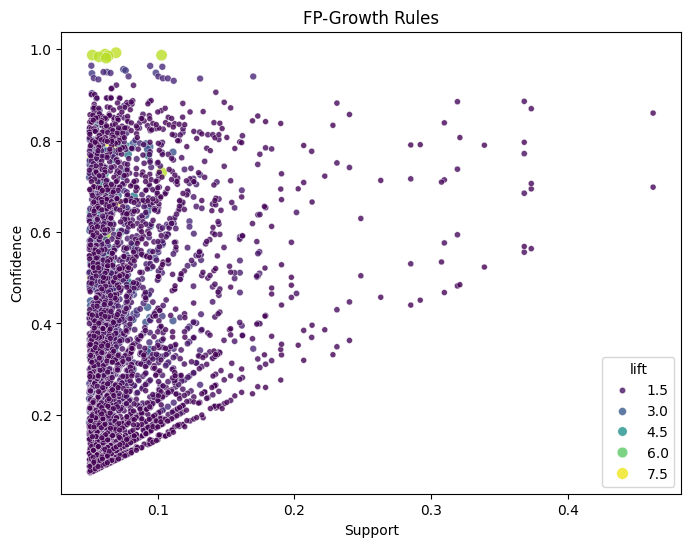

In [83]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="support",
    y="confidence",
    hue="lift",
    size="lift",
    data=rules_fp,
    palette="viridis",
    alpha=0.8
)

plt.title("FP-Growth Rules")
plt.xlabel("Support")
plt.ylabel("Confidence")

# Show the plot
plt.show()



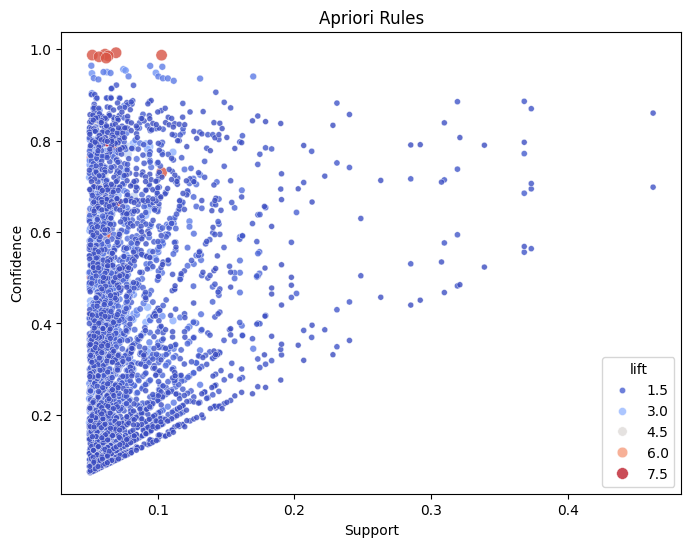

In [84]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="support",
    y="confidence",
    hue="lift",
    size="lift",
    data=rules_apr,
    palette="coolwarm",
    alpha=0.8
)

plt.title("Apriori Rules")
plt.xlabel("Support")
plt.ylabel("Confidence")

plt.show()

In [133]:
pd.set_option('display.max_rows', 70)
good_rules = rules_apr[
    (rules_apr['support'] >= 0.05) &
    (rules_apr['confidence'] >= 0.75) &
    (rules_apr['lift'] >= 1.5) &
    (rules_apr['lift'] <= 2)
]
print(len(good_rules))
good_rules.sort_values(by="lift", ascending=False).head(70)

69


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1805,"(rating:High, tag:Mystery)",(genre:Adventure),0.067166,0.432834,0.057452,0.855372,1.976214,1.0,0.028380,3.921550,0.529550,0.129821,0.744999,0.494053
61,(tag:Mystery),(genre:Adventure),0.083541,0.432834,0.070774,0.847176,1.957278,1.0,0.034615,3.711240,0.533670,0.158829,0.730548,0.505345
1525,"(tag:Sci-fi, tag:Shooter)",(genre:Action),0.053428,0.492923,0.051485,0.963636,1.954945,1.0,0.025149,13.944629,0.516048,0.104038,0.928288,0.534042
1472,"(tag:Shooter, tag:First-Person)",(genre:Action),0.098113,0.492923,0.094505,0.963225,1.954110,1.0,0.046143,13.788606,0.541374,0.190330,0.927476,0.577474
1325,"(price:Free, genre:Action)",(tag:Multiplayer),0.068415,0.394810,0.052734,0.770791,1.952309,1.0,0.025723,2.640343,0.523609,0.128465,0.621261,0.452179
1077,"(tag:Open World, ccu:Medium)",(playtime:Long),0.070636,0.408965,0.056342,0.797642,1.950394,1.0,0.027454,2.920747,0.524319,0.133115,0.657622,0.467705
1491,"(tag:Multiplayer, tag:Shooter)",(genre:Action),0.107549,0.492923,0.103386,0.961290,1.950185,1.0,0.050373,13.099500,0.545944,0.207984,0.923661,0.585516
439,"(ccu:Low, tag:Mystery)",(genre:Adventure),0.067444,0.432834,0.056897,0.843621,1.949066,1.0,0.027705,3.626879,0.522149,0.128326,0.724281,0.487537
1391,"(rating:Medium, tag:Shooter)",(genre:Action),0.063558,0.492923,0.060366,0.949782,1.926837,1.0,0.029037,10.097455,0.513662,0.121678,0.900965,0.536124
1061,"(price:Middle, ccu:Medium)",(playtime:Long),0.069387,0.408965,0.054677,0.788000,1.926816,1.0,0.026300,2.787902,0.516873,0.129053,0.641307,0.460848


# **CLUSTERIZATION**

---
---
---
---
---
---
---
---
---
---
---
---
---
---
---


In [86]:
!pip install pyclustering

In [87]:
import time
import tracemalloc
import sys

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from pyclustering.cluster.kmedians import kmedians
from sklearn.cluster import kmeans_plusplus
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KNeighborsClassifier, kneighbors_graph
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score, classification_report, davies_bouldin_score, calinski_harabasz_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

In [88]:
df_cl = df.drop(columns = ['AppID'])

In [89]:
MIN_REVIEWS = 1000

df_cl = df_cl[(df_cl["Positive"] + df_cl["Negative"]) >= MIN_REVIEWS]

df_cl["Rating_ratio"] = df_cl["Positive"] / (df_cl["Positive"] + df_cl["Negative"]).replace(0, np.nan)
df_cl["Language_count"] = df_cl["Supported languages"].apply(lambda x: len(parse_list_field(x)))
df_cl["Release_year"] = df_cl["Release_year"] = pd.to_datetime( df_cl["Release date"], format="%b %d, %Y", errors="coerce").dt.year
df_cl["Platform_count"] = df_cl[["Windows", "Mac", "Linux"]].sum(axis=1)

genres_encoded = df_cl["Genres"].apply(parse_list_field).str.join("|").str.get_dummies()

numeric_features = [
    "Price", "Peak CCU", "Recommendations",
    "Average playtime forever", "Median playtime forever",
    "Rating_ratio", "Language_count",
    "Platform_count"
]

df_cl = pd.concat([df_cl[numeric_features], genres_encoded], axis=1)
df_cl = df_cl.dropna()
df_cl.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7206 entries, 12 to 122593
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Price                     7206 non-null   float64
 1   Peak CCU                  7206 non-null   int64  
 2   Recommendations           7206 non-null   int64  
 3   Average playtime forever  7206 non-null   int64  
 4   Median playtime forever   7206 non-null   int64  
 5   Rating_ratio              7206 non-null   float64
 6   Language_count            7206 non-null   int64  
 7   Platform_count            7206 non-null   int64  
 8   Action                    7206 non-null   int64  
 9   Adventure                 7206 non-null   int64  
 10  Animation & Modeling      7206 non-null   int64  
 11  Audio Production          7206 non-null   int64  
 12  Casual                    7206 non-null   int64  
 13  Design & Illustration     7206 non-null   int64  
 14  Early Acce

In [90]:
df_cl = df_cl.dropna()

In [91]:
df_cl["Rating_bucket"] = pd.cut(
    df_cl["Rating_ratio"],
    bins=[0.0, 0.50, 0.80, 1.01],
    labels=["Low", "Medium", "High"]
)

print("Rating bucket counts:")
print(df_cl["Rating_bucket"].value_counts())
df_cl = df_cl.dropna(subset=["Rating_bucket"])

y_true = df_cl["Rating_bucket"].values

df_cl = df_cl.drop(columns=["Rating_bucket", "Rating_ratio", "Recommendations"])


Rating bucket counts:
Rating_bucket
High      4955
Medium    2096
Low        155
Name: count, dtype: int64


In [92]:
df_cl.skew(numeric_only = True)

,0
Price,2.622451
Peak CCU,52.091170
Average playtime forever,22.674126
Median playtime forever,39.095063
Language_count,5.907724
Platform_count,1.011041
Action,0.028318
Adventure,0.271179
Animation & Modeling,21.155698
Audio Production,37.931513


In [93]:
log_cols  = ["Price", "Peak CCU", "Average playtime forever",
             "Median playtime forever"]
sqrt_cols = ["Language_count", "Platform_count"]

for col in log_cols:
    df_cl[col] = np.log1p(df_cl[col])

for col in sqrt_cols:
    df_cl[col] = np.sqrt(df_cl[col])

In [94]:
numeric_cols = ["Price", "Peak CCU", "Average playtime forever",
                "Median playtime forever", "Language_count",
                "Platform_count"]

print(df_cl[numeric_cols].skew())

Price                      -0.130707
Peak CCU                    0.726961
Average playtime forever   -1.294567
Median playtime forever    -1.274588
Language_count              0.978379
Platform_count              0.914252
dtype: float64


In [95]:
binary_cols = [col for col in df_cl.columns if col not in numeric_cols]

In [96]:
scaler = RobustScaler()

X_scaled = scaler.fit_transform(df_cl[numeric_cols])

In [97]:
results = []
def record(name, labels, X, y_true,
           elapsed=None, memory_mb=None):

    X = np.asarray(X)
    labels = np.asarray(labels)

    unique_labels = set(labels) - {-1}
    n_clusters = len(unique_labels)
    noise_pct = round((labels == -1).sum() / len(labels) * 100, 2)

    fl = labels != -1
    X_fl = X[fl]
    labels_fl = labels[fl]

    if n_clusters < 2:
        sil, dbi, chi = None, None, None
    elif len(labels) > 10_000:
        idx = np.random.choice(len(labels_fl), 10_000, replace=False)
        sil = silhouette_score(X_fl[idx], labels_fl[idx])
        dbi = davies_bouldin_score(X_fl[idx], labels_fl[idx])
        chi = calinski_harabasz_score(X_fl[idx], labels_fl[idx])
    else:
        sil = silhouette_score(X_fl, labels_fl)
        dbi = davies_bouldin_score(X_fl, labels_fl)
        chi = calinski_harabasz_score(X_fl, labels_fl)

    ari = adjusted_rand_score(y_true, labels)
    inertia = compute_inertia(X, labels) if n_clusters >= 2 else None

    results.append({
        "Algorithm":   name,
        "N of clusters":  n_clusters,
        "Silhouette":  round(sil, 4) if sil is not None else None,
        "DBI":         round(dbi, 4) if dbi is not None else None,
        "CHI":         round(chi, 4) if chi is not None else None,
        "ARI":         round(ari, 4),
        "Noise %":     noise_pct,
        "Inertia":     round(inertia, 2) if inertia is not None else None,
        "Time (s)":    round(elapsed, 2) if elapsed is not None else None,
        "Memory (MB)": round(memory_mb, 2) if memory_mb is not None else None,
    })

    print(f"{name} | N of clusters={n_clusters} | Time={elapsed:.2f}s | Mem={memory_mb:.2f}MB")

def compute_inertia(X, labels):
    inertia = 0.0
    for label in set(labels) - {-1}:
        cluster_points = X[labels == label]
        centroid = cluster_points.mean(axis=0)
        inertia += ((cluster_points - centroid) ** 2).sum()
    return inertia

In [98]:
inertias = []
silhouettes = []
best_k = None
best_labels = None
best_sil = -1
best_elapsed = None
best_memory_mb = None

for k in range(2, 9):
    tracemalloc.start()
    t0 = time.time()

    model = KMeans(n_clusters=k, random_state=393, n_init=10)
    labels = model.fit_predict(X_scaled)

    elapsed = time.time() - t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    memory_mb = peak / 1024 / 1024

    inertias.append(model.inertia_)

    sampled_labels = labels

    if len(set(sampled_labels)) > 2:
        sil = silhouette_score(X_scaled, sampled_labels)
        record("K-Means", labels, X_scaled, y_true,
           elapsed=elapsed, memory_mb=memory_mb)
    else:
        sil = -1

    silhouettes.append(sil)

    if sil > best_sil:
        best_sil = sil
        best_k = k
        best_labels = labels
        best_elapsed = elapsed
        best_memory_mb = memory_mb


K-Means | N of clusters=3 | Time=0.22s | Mem=1.00MB
K-Means | N of clusters=4 | Time=0.81s | Mem=1.00MB
K-Means | N of clusters=5 | Time=0.60s | Mem=1.00MB
K-Means | N of clusters=6 | Time=0.50s | Mem=1.00MB
K-Means | N of clusters=7 | Time=1.30s | Mem=1.00MB
K-Means | N of clusters=8 | Time=0.67s | Mem=1.17MB


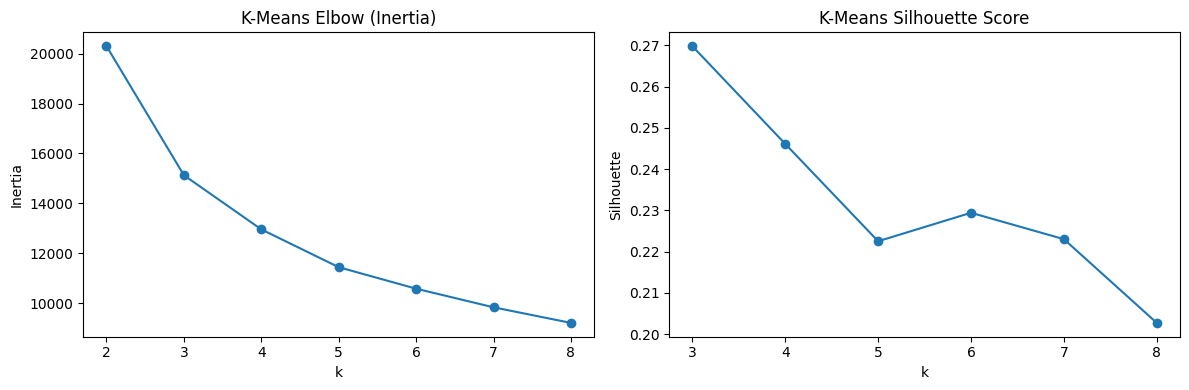

In [99]:
ks = list(range(2, 9))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ks, inertias, "o-")
axes[0].set_title("K-Means Elbow (Inertia)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

silhouettes = [r["Silhouette"] for r in results]
axes[1].plot(ks[1:], silhouettes, "o-")
axes[1].set_title("K-Means Silhouette Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

In [100]:
results = [r for r in results if r["Algorithm"] != "K-Means" or r["N of clusters"] == 6]
for r in results:
    print(f"Algorithm: {r['Algorithm']} | k={r['N of clusters']} | Silhouette: {r['Silhouette']}")

Algorithm: K-Means | k=6 | Silhouette: 0.2294


In [101]:
test_model = KMeans(n_clusters=6, random_state=393, n_init=10)
test_labels = test_model.fit_predict(X_scaled)

unique, counts = np.unique(test_labels, return_counts=True)
print("Games per cluster at k=6:", dict(zip(unique, counts)))

Games per cluster at k=6: {np.int32(0): np.int64(1466), np.int32(1): np.int64(1264), np.int32(2): np.int64(1562), np.int32(3): np.int64(222), np.int32(4): np.int64(564), np.int32(5): np.int64(2128)}


In [102]:
def profile_clusters(df_original, labels, numeric_cols, binary_cols):
    df_copy = df_original.copy()
    df_copy["Cluster"] = labels

    unique_clusters = sorted(df_copy["Cluster"].unique())

    print("### Average Stats per Cluster ###")
    numeric_profile = df_copy.groupby("Cluster")[numeric_cols].mean()
    readable_numeric = numeric_profile.copy()

    # Reverse transformations
    for col in ["Price", "Average playtime forever", "Median playtime forever"]:
        if col in readable_numeric.columns:
            readable_numeric[col] = np.expm1(readable_numeric[col])

    if "Language_count" in readable_numeric.columns:
        readable_numeric["Language_count"] = readable_numeric["Language_count"] ** 2

    if "Peak CCU" in readable_numeric.columns:
        readable_numeric["Peak CCU"] = np.expm1(readable_numeric["Peak CCU"])

    if "Platform_count" in readable_numeric.columns:
        readable_numeric["Platform_count"] = readable_numeric["Platform_count"] ** 2

    print(readable_numeric.round(2))
    print("\n")

    print("### Genres per Cluster ###")
    genre_profile = df_copy.groupby("Cluster")[binary_cols].mean()
    actual_genres = [col for col in binary_cols]

    for cluster in unique_clusters:
        cluster_size = len(df_copy[df_copy["Cluster"] == cluster])

        # DBSCAN edge case
        cluster_name = f"Cluster {cluster}" if cluster != -1 else "Noise (-1)"
        print(f"{cluster_name} (Size: {cluster_size}):")

        top_genres = genre_profile.loc[cluster][actual_genres].sort_values(ascending=False).head(5)

        for genre, percentage in top_genres.items():
            if percentage > 0.05:
                print(f"  - {genre}: {percentage * 100:.1f}%")
        print("-" * 20)

In [103]:
def plot_pca_clusters(X_scaled, labels, name):

    pca = PCA(n_components=2, random_state=42)
    components = pca.fit_transform(X_scaled)

    df_pca = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
    df_pca['Cluster'] = labels

    plt.figure(figsize=(12, 8))

    unique_labels = sorted(set(labels))
    standard_clusters = [l for l in unique_labels if l != -1]
    palette = sns.color_palette("hls", n_colors=len(standard_clusters))

    color_dict = {}
    color_idx = 0
    for l in unique_labels:
        if l == -1:
            color_dict[l] = (0.7, 0.7, 0.7, 0.5)
        else:
            color_dict[l] = palette[color_idx]
            color_idx += 1

    scatter = sns.scatterplot(
        x='PC1', y='PC2',
        hue='Cluster',
        data=df_pca,
        palette=color_dict,
        alpha=0.6,
        edgecolor='w',
        s=50
    )

    plt.title(f'2D PCA Projection of Game Clusters ({name})', fontsize=16)
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f"Total variance explained by 2 components: {sum(pca.explained_variance_ratio_)*100:.2f}%")

K-means з K = 6, створив кластери зміст кожного з яких можна інтерпретувати як:


*   0: Низька ціна, Низький онлайн, Низький середній час гри - це дешеві та короткі ігри, які швидко проходяться або ж купляються за знижками у великих масштабах.
*   1: Висока ціна, Високий онлайн, Високий середній час у грі - преміальні ААА продукти та загалом успішні ігри переважно потрапили саме в цю категорію
*   2: Висока кількість платформ, Низька ціна, Підтримака мов - це категорія Інді ігор які намагаються охопити найбільшу кількість аудиторії.
*   3: Дуже низька ціна, Дуже низький онлайн, Дуже низький середній час гри - це категорія "мертвих" безкоштовних ігор, або ж ігор зроблених в якості жарту
*   4: Дуже низька ціна, Високий онлайн, Високий середній час у порівнянні з медіаною - це категорія безкоштовних live-service ігор, які існують вже давно та мають велику аудиторію, проте через свою безкоштовність, багато людей заходять спробувати проте не затримаються надовго що індикується великою різницею в середньому часі та медіані
*   5: Найбільший кластер, Середня ціна, Середній проведений час - це середнячки, до яких відноситься більшість ігор які мали обмежений успіх.



In [104]:
profile_clusters(df_cl, test_labels, numeric_cols, binary_cols)


### Average Stats per Cluster ###
         Price  Peak CCU  Average playtime forever  Median playtime forever  \
Cluster                                                                       
0         1.47      3.31                    146.28                    81.03   
1        11.39    401.81                   2461.69                  1141.13   
2         3.67     10.67                    351.56                   213.80   
3         0.71      2.26                      0.01                     0.01   
4         0.41    165.00                   1490.33                   209.43   
5         7.69     19.38                    519.20                   343.71   

         Language_count  Platform_count  
Cluster                                  
0                  4.96            1.18  
1                  8.66            1.32  
2                  7.03            2.66  
3                  4.62            1.51  
4                  8.41            1.35  
5                  7.00            1.04

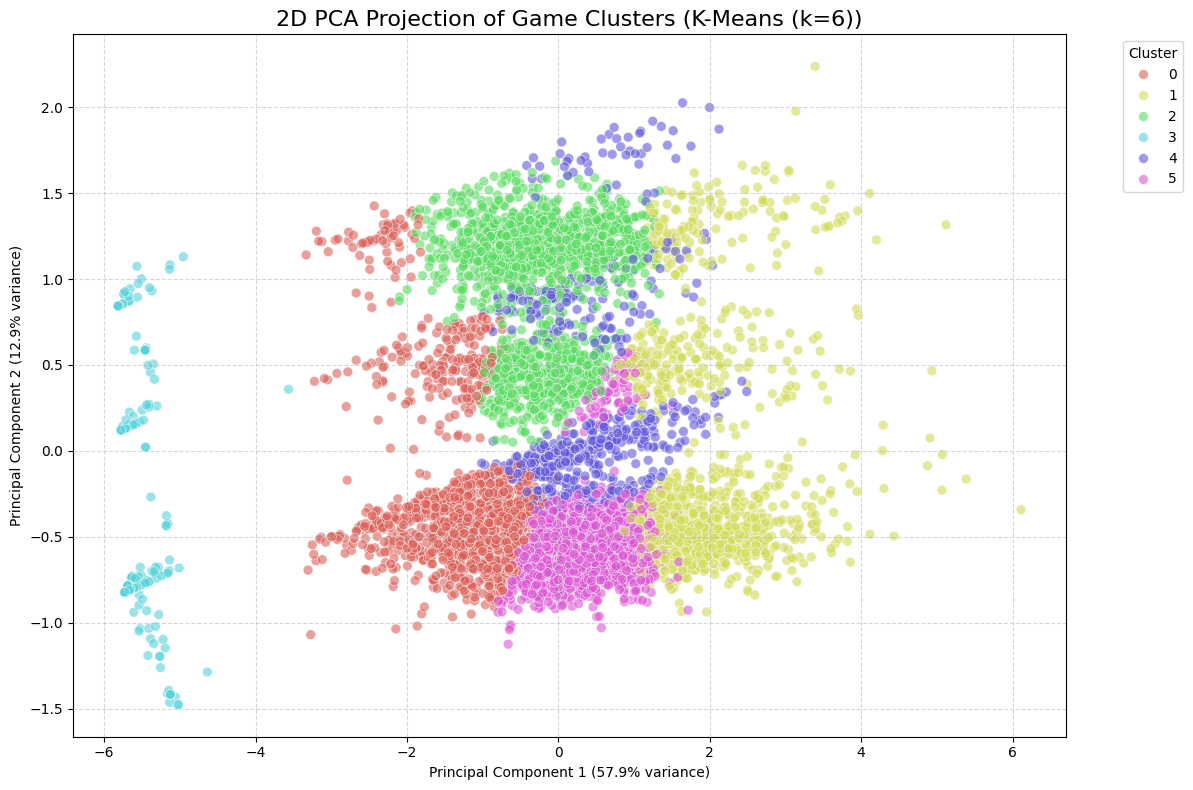

Total variance explained by 2 components: 70.86%


In [105]:
plot_pca_clusters(X_scaled, test_labels, "K-Means (k=6)")

In [106]:
K = 6
X_list = X_scaled.tolist()

initial_medians_array, _ = kmeans_plusplus(X_scaled, n_clusters=K, random_state=393)

initial_medians = initial_medians_array.tolist()

kmed = kmedians(X_list, initial_medians)

tracemalloc.start()
t0 = time.time()

kmed.process()

elapsed = time.time() - t0
_, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
memory_mb = peak / 1024 / 1024

py_clusters = kmed.get_clusters()

labels_kmed = np.zeros(len(X_list), dtype=int)
for cluster_id, cluster_indices in enumerate(py_clusters):
    for idx in cluster_indices:
        labels_kmed[idx] = cluster_id

print(f"K-Medians Complete | Time: {elapsed:.2f}s | Mem: {memory_mb:.2f}MB")

record(
    "K-Medians",
    labels=labels_kmed,
    X=X_scaled,
    y_true=y_true,
    elapsed=elapsed,
    memory_mb=memory_mb
)

K-Medians Complete | Time: 2.97s | Mem: 8.71MB
K-Medians | N of clusters=6 | Time=2.97s | Mem=8.71MB


K-medians з K = 6, створив кластери зміст кожного з яких можна інтерпретувати як:


*   0: Середня ціна, Середній онлайн - даний кластер є комбінацією
*   1: Мала розмірність, Нереалістичні показники - це категорія екстримальних викидів, де ігри скоріш за все мають навмисно зманіпульовані показники про що можна судити з підтримки 100 мов
*   2: Висока ціна, Високий онлайн, Високий середній час у грі - преміальні ААА продукти та загалом успішні ігри переважно потрапили саме в цю категорію
*   3: Висока кількість, середні показники - даний кластер є комбінацією ігор жанрів Інді та Action, K-medians не зміг доцільно їх розподілити.
*   4: Дуже низька ціна, Дуже низький онлайн, Дуже низький середній час гри - це категорія "мертвих" безкоштовних ігор, або ж ігор зроблених в якості жарту
*   5: Середня ціна, Високий середній час гри, Низький онлайн - нішеві ігри які затягують надовго, враховуючи переважаючі показники стратегій та RPG в даному кластері



In [107]:
profile_clusters(df_cl, labels_kmed, numeric_cols, binary_cols)

### Average Stats per Cluster ###
         Price  Peak CCU  Average playtime forever  Median playtime forever  \
Cluster                                                                       
0         8.15    218.55                   1796.72                   582.10   
1         0.50      5.03                    342.41                   112.91   
2         9.53    652.49                   1036.96                   553.62   
3         2.94      6.97                    242.49                   141.11   
4         0.69      2.17                      0.18                     0.17   
5         5.47     40.44                   1269.05                   689.66   

         Language_count  Platform_count  
Cluster                                  
0                  7.09            1.97  
1                 99.70            1.03  
2                 15.70            1.66  
3                  5.98            1.45  
4                  4.47            1.51  
5                  6.30            1.07

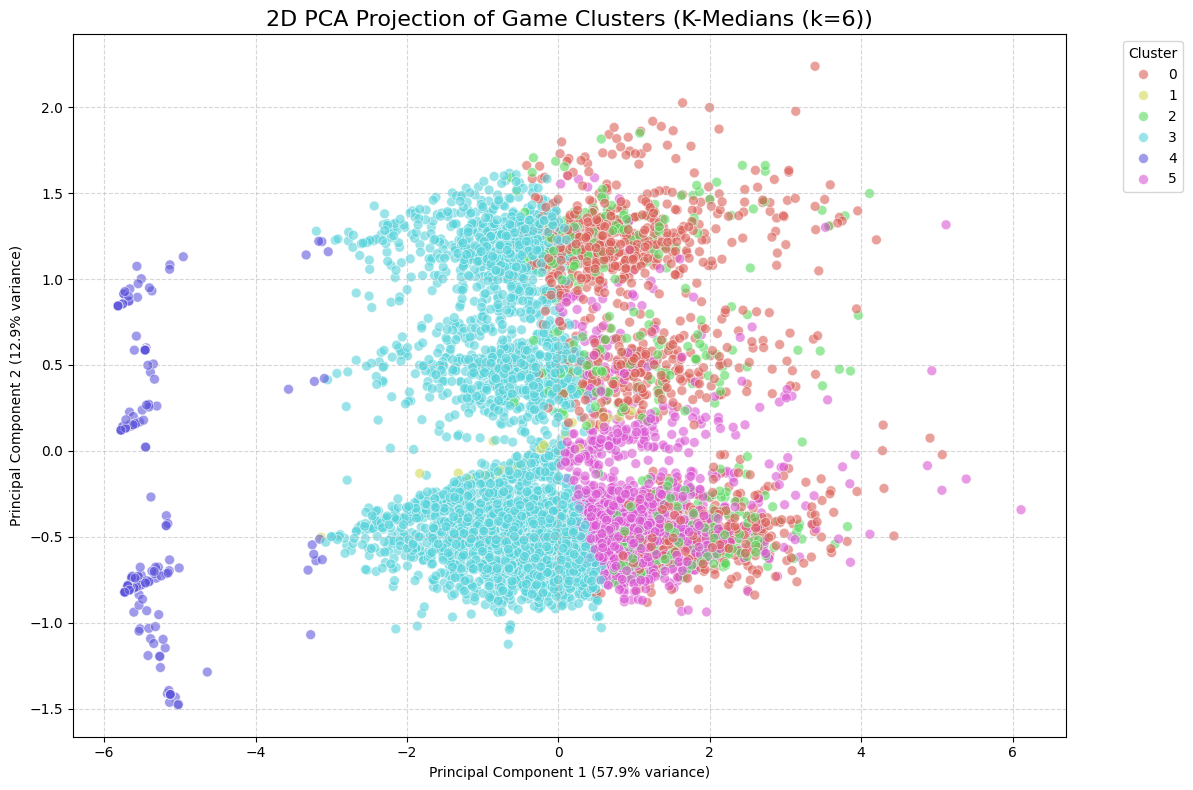

Total variance explained by 2 components: 70.86%


In [108]:
plot_pca_clusters(X_scaled, labels_kmed, f"K-Medians (k={K})")

In [109]:
tracemalloc.start()
t0 = time.time()

model = AgglomerativeClustering(n_clusters=K, linkage='single')
labels_sng = model.fit_predict(X_scaled)

elapsed = time.time() - t0
_, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
memory_mb = peak / 1024 / 1024

print(f"Algorithm Complete | Time: {elapsed:.2f}s | Mem: {memory_mb:.2f}MB\n")

record(
      f"Agglomerative Single",
      labels=labels_sng,
      X=X_scaled,
      y_true=y_true,
      elapsed=elapsed,
      memory_mb=memory_mb
)

Algorithm Complete | Time: 1.55s | Mem: 1.05MB

Agglomerative Single | N of clusters=6 | Time=1.55s | Mem=1.05MB


In [110]:
profile_clusters(df_cl, labels_sng, numeric_cols, binary_cols)

### Average Stats per Cluster ###
         Price  Peak CCU  Average playtime forever  Median playtime forever  \
Cluster                                                                       
0         0.71      2.29                      0.00                     0.00   
1         3.35      0.73                 107857.48                   165.28   
2         4.38     25.57                    526.01                   273.40   
3         0.50      5.42                    380.71                   121.77   
4         0.00      0.00                      0.00                     0.00   
5         0.00      0.00                 148281.00                222407.00   

         Language_count  Platform_count  
Cluster                                  
0                  4.52            1.50  
1                  1.00            2.00  
2                  6.77            1.45  
3                102.90            1.03  
4                 74.00            3.00  
5                  4.00            2.00

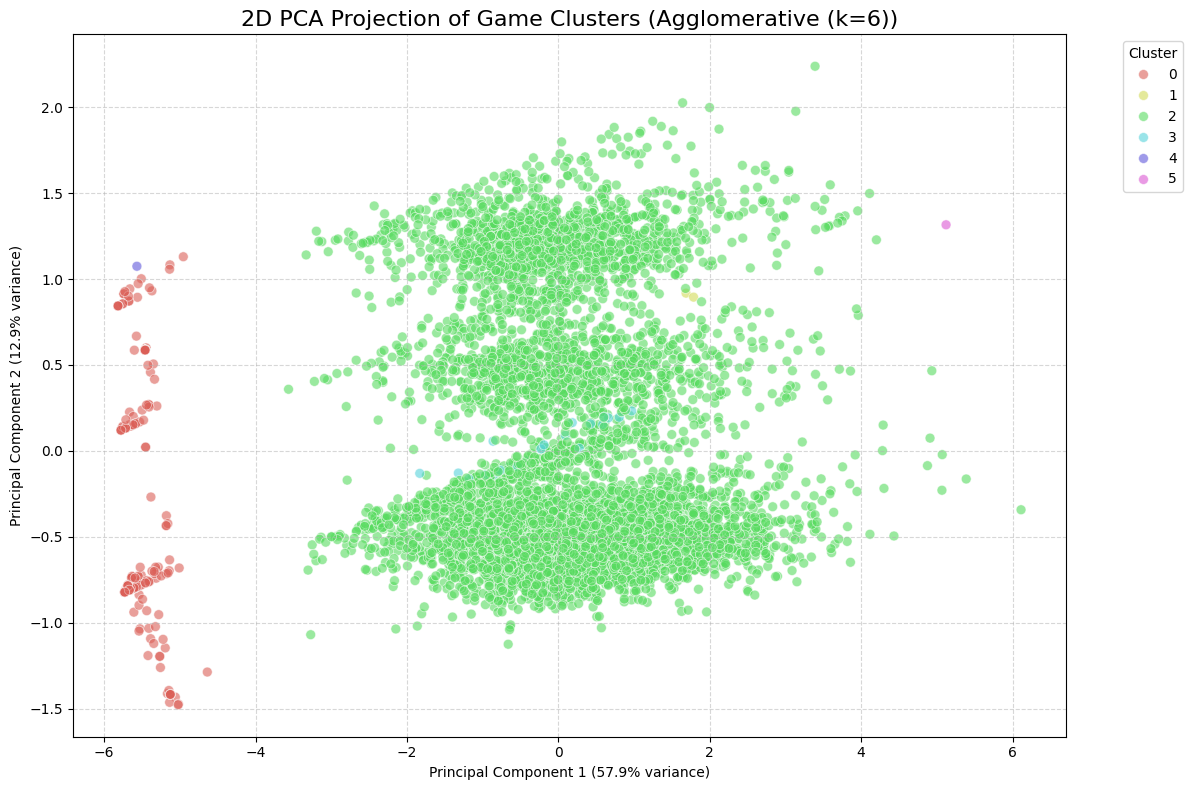

Total variance explained by 2 components: 70.86%


In [111]:
plot_pca_clusters(X_scaled, labels_sng, f"Agglomerative (k={K})")

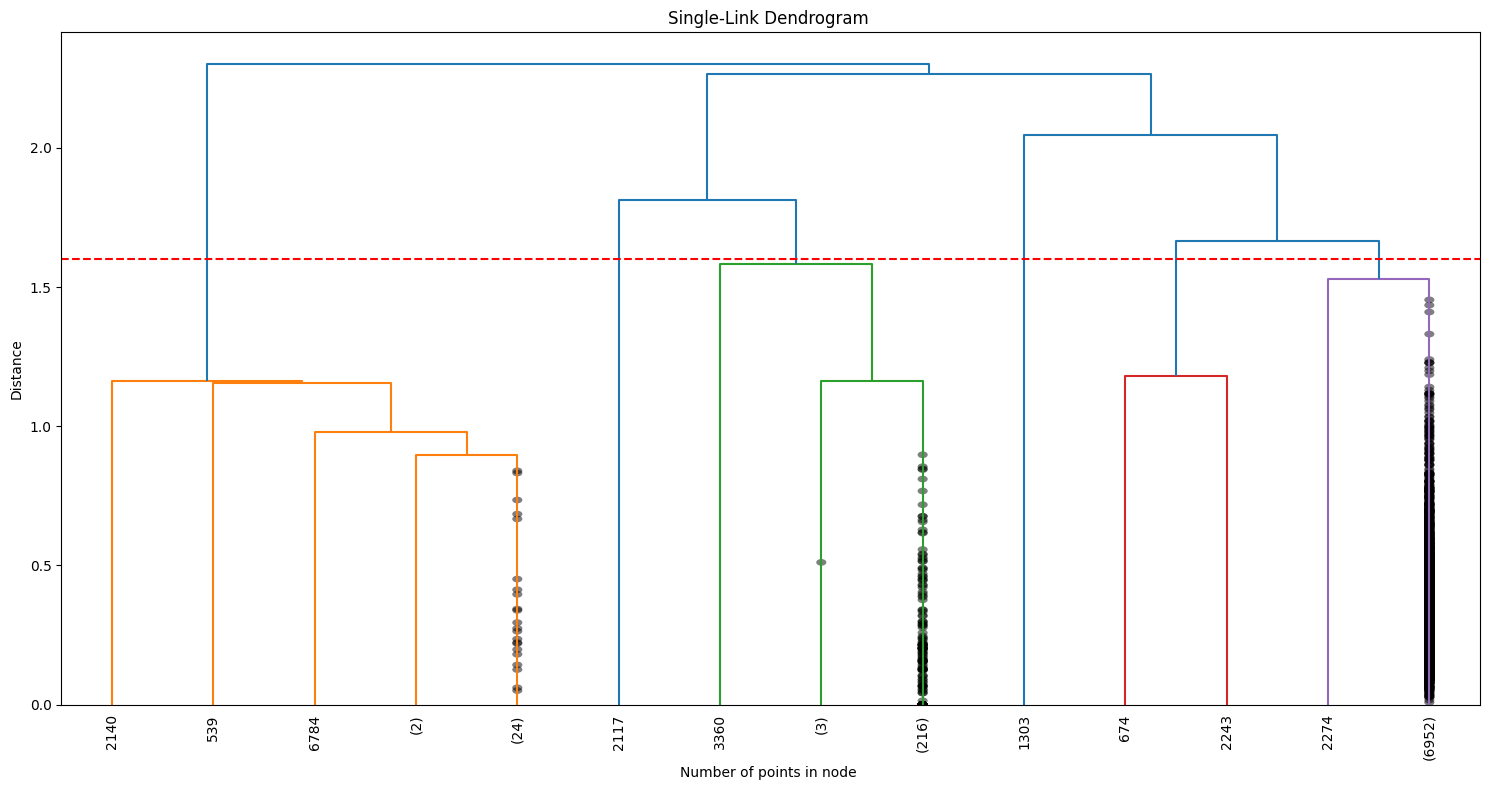

In [112]:

Z = linkage(X_scaled, method='single')
sys.setrecursionlimit(10000)
plt.figure(figsize=(15, 8))
plt.title('Single-Link Dendrogram ')
plt.xlabel('Number of points in node ')
plt.ylabel('Distance')

dendrogram(
    Z,
    truncate_mode='level',
    p=4,
    show_leaf_counts=True,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True,
)

plt.axhline(y=1.6, color='r', linestyle='--')

plt.tight_layout()
plt.show()

In [113]:
tracemalloc.start()
t0 = time.time()

model = AgglomerativeClustering(n_clusters=K, linkage='complete')
labels_cmp = model.fit_predict(X_scaled)

elapsed = time.time() - t0
_, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
memory_mb = peak / 1024 / 1024

print(f"Algorithm Complete | Time: {elapsed:.2f}s | Mem: {memory_mb:.2f}MB\n")

record(
      f"Agglomerative Complete",
      labels=labels_cmp,
      X=X_scaled,
      y_true=y_true,
      elapsed=elapsed,
      memory_mb=memory_mb
)

Algorithm Complete | Time: 3.11s | Mem: 222.82MB

Agglomerative Complete | N of clusters=6 | Time=3.11s | Mem=222.82MB


In [114]:
profile_clusters(df_cl, labels_cmp, numeric_cols, binary_cols)

### Average Stats per Cluster ###
         Price  Peak CCU  Average playtime forever  Median playtime forever  \
Cluster                                                                       
0         8.32    133.94                   1557.42                   708.46   
1         3.00      9.51                    282.53                   157.90   
2         0.71      2.27                      0.00                     0.00   
3         0.19   7558.57                  22101.99                  6633.65   
4         0.50      5.42                    380.71                   121.77   
5         8.35     12.95                  95090.79                124788.87   

         Language_count  Platform_count  
Cluster                                  
0                  7.38            1.34  
1                  6.42            1.52  
2                  4.65            1.50  
3                 14.68            1.46  
4                102.90            1.03  
5                  3.58            1.17

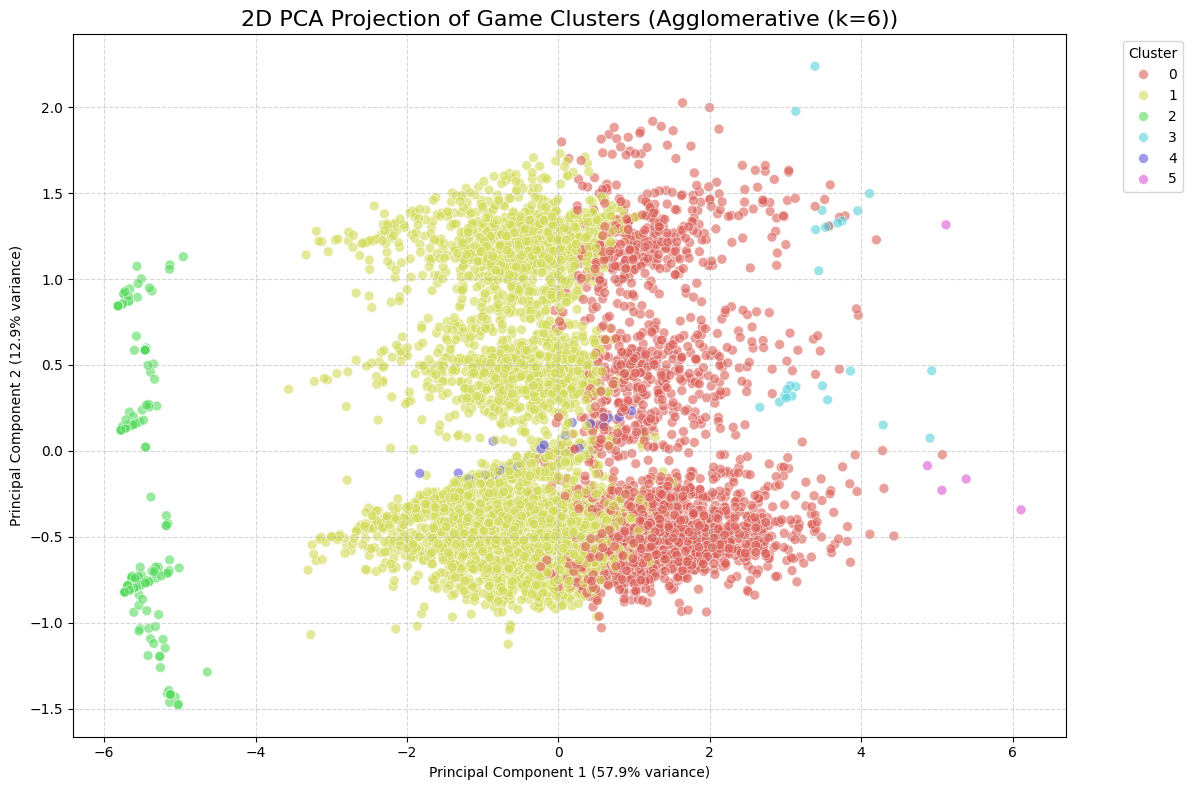

Total variance explained by 2 components: 70.86%


In [115]:
plot_pca_clusters(X_scaled, labels_cmp, f"Agglomerative (k={K})")

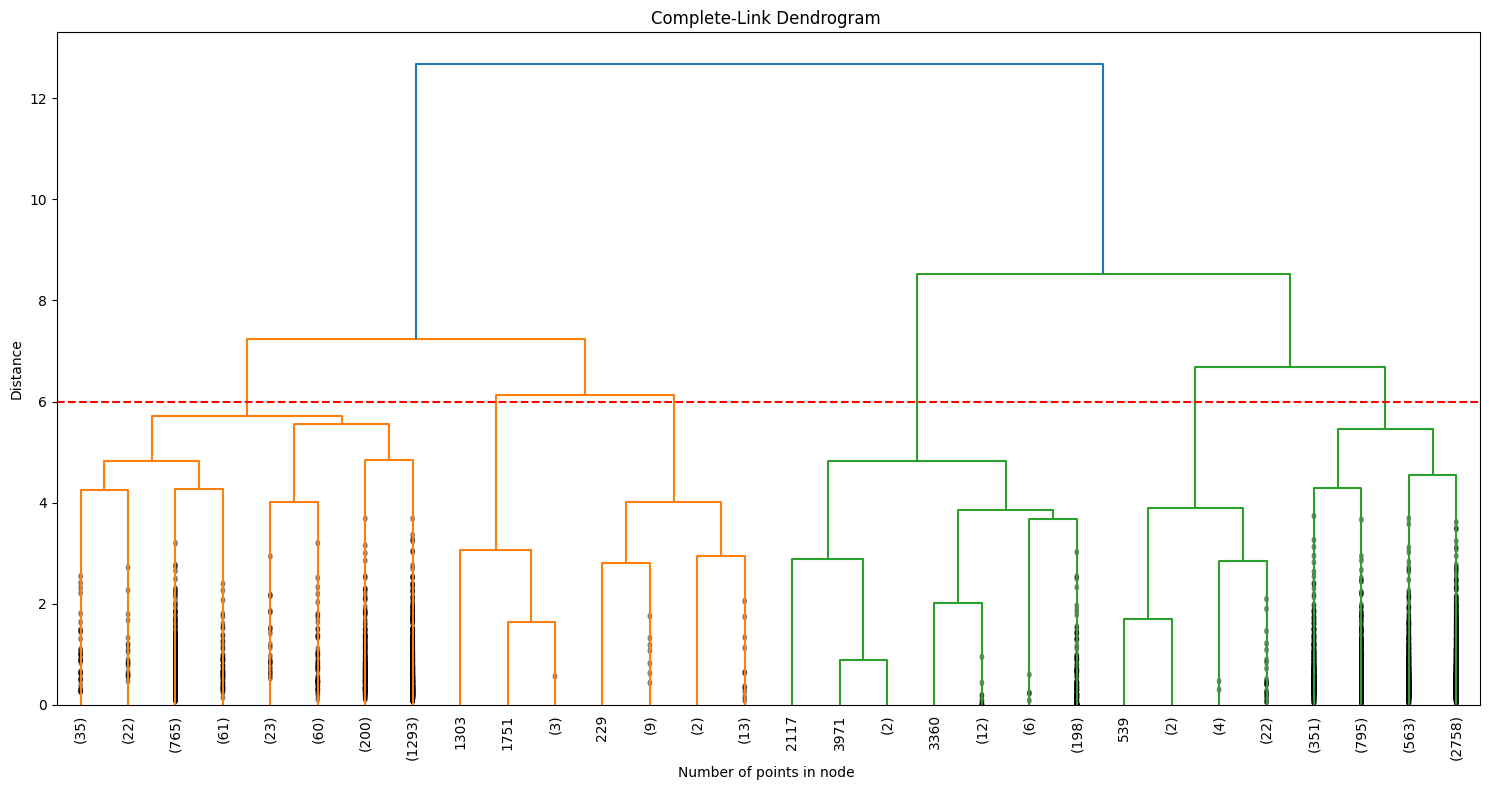

In [116]:

Z = linkage(X_scaled, method='complete')
plt.figure(figsize=(15, 8))
plt.title('Complete-Link Dendrogram ')
plt.xlabel('Number of points in node ')
plt.ylabel('Distance')

dendrogram(
    Z,
    truncate_mode='level',
    p=4,
    show_leaf_counts=True,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True,
)

plt.axhline(y=6, color='r', linestyle='--')

plt.tight_layout()
plt.show()

In [117]:
tracemalloc.start()
t0 = time.time()

model = AgglomerativeClustering(n_clusters=K, linkage='ward')
labels_wrd = model.fit_predict(X_scaled)

elapsed = time.time() - t0
_, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
memory_mb = peak / 1024 / 1024

print(f"Algorithm Complete | Time: {elapsed:.2f}s | Mem: {memory_mb:.2f}MB\n")

record(
      f"Agglomerative Ward",
      labels=labels_wrd,
      X=X_scaled,
      y_true=y_true,
      elapsed=elapsed,
      memory_mb=memory_mb
)

Algorithm Complete | Time: 3.42s | Mem: 222.82MB

Agglomerative Ward | N of clusters=6 | Time=3.42s | Mem=222.82MB


Ward з K = 6, створив кластери зміст кожного з яких можна інтерпретувати як:


*   0: Низька ціна, Низький онлайн, Низький проведений час - бюджетна категорія ігор
*   1: Мультиплатформенні, Низька ціна, Високий середній час - дешеві та успішні проєкти
*   2: Мультиплатформенні, Низька ціна, Низький середній час - дешеві та невеличкі Інді проєкти
*   3: Середня ціна, Низький онлайн, Середній проведений час - середнячки та переважно однокористувацькі сюжетні ігри.
*   4: Одна платформа, Висока ціна, Високий онлайн - успішні ААА проєкти
*   5: Дуже низька ціна, Дуже низький онлайн, Дуже низький середній час гри - це категорія "мертвих" безкоштовних ігор, або ж ігор зроблених в якості жарту



In [118]:
profile_clusters(df_cl, labels_wrd, numeric_cols, binary_cols)

### Average Stats per Cluster ###
         Price  Peak CCU  Average playtime forever  Median playtime forever  \
Cluster                                                                       
0         1.58      5.19                    190.29                    95.11   
1         3.77    110.76                   1012.14                   355.25   
2         2.96      3.45                    237.52                   168.59   
3         7.99     22.48                    615.81                   388.17   
4        11.29    497.93                   2569.77                  1197.62   
5         0.71      2.27                      0.00                     0.00   

         Language_count  Platform_count  
Cluster                                  
0                  6.21            1.13  
1                  8.20            2.28  
2                  5.38            2.60  
3                  6.52            1.00  
4                  9.53            1.06  
5                  4.65            1.50

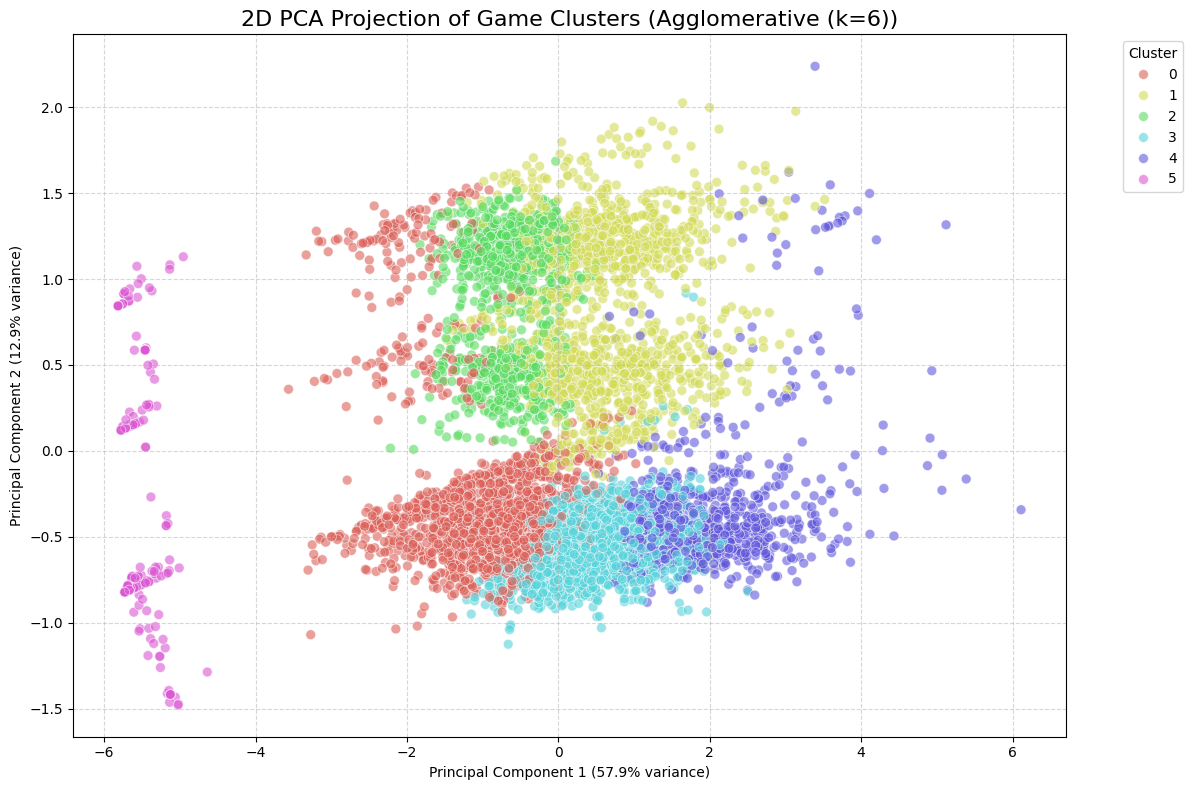

Total variance explained by 2 components: 70.86%


In [119]:
plot_pca_clusters(X_scaled, labels_wrd, f"Agglomerative (k={K})")

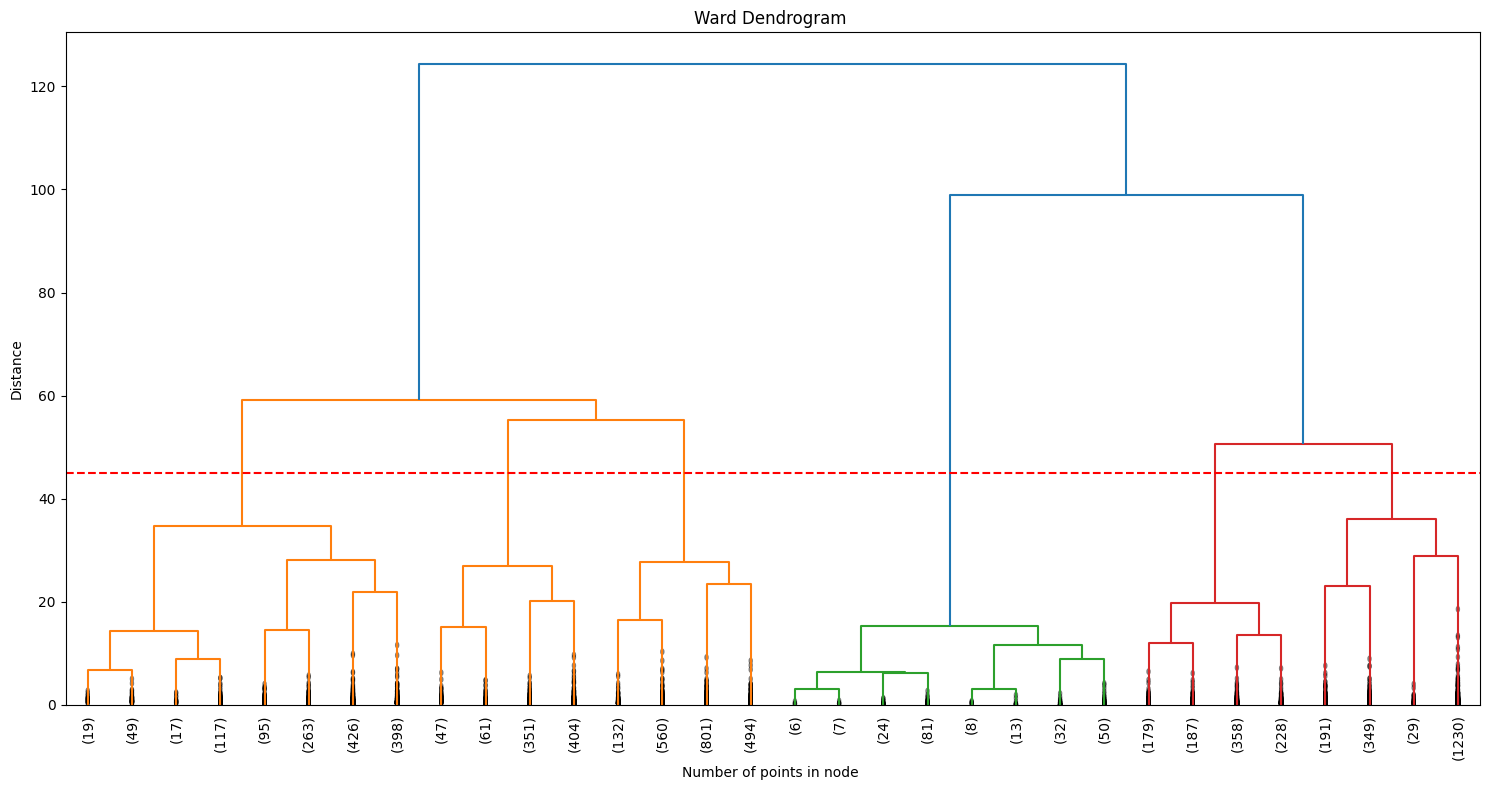

In [120]:
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(15, 8))
plt.title('Ward Dendrogram ')
plt.xlabel('Number of points in node ')
plt.ylabel('Distance')

dendrogram(
    Z,
    truncate_mode='level',
    p=4,
    show_leaf_counts=True,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True,
)

plt.axhline(y=45, color='r', linestyle='--')

plt.tight_layout()
plt.show()

Calculating Nearest Neighbors for K-Distance Graph...


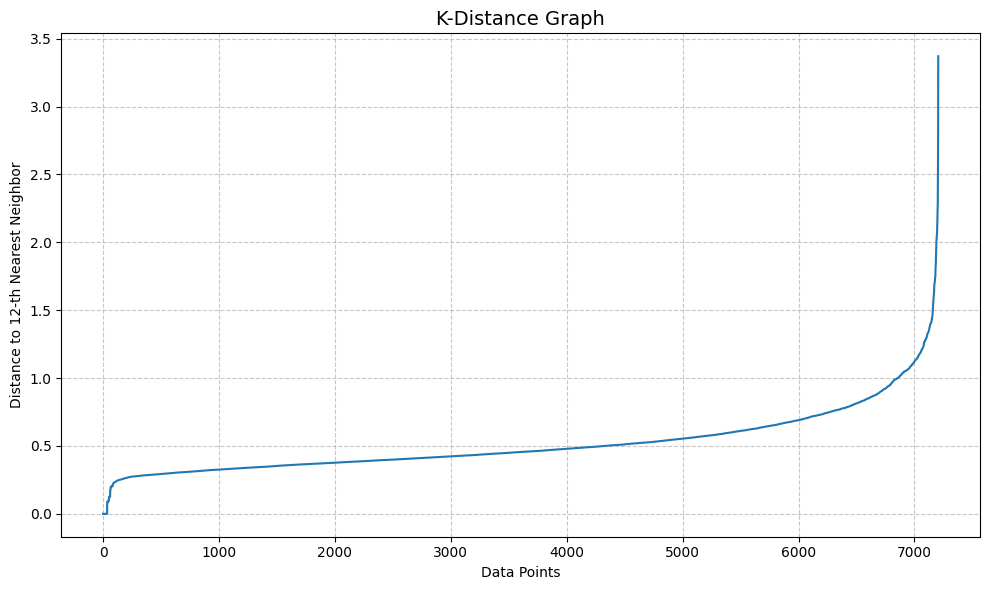

In [121]:
min_samples = 12

print("Calculating Nearest Neighbors for K-Distance Graph...")
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_scaled)

distances, indices = nn.kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title('K-Distance Graph', fontsize=14)
plt.xlabel('Data Points')
plt.ylabel(f'Distance to 12-th Nearest Neighbor')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [122]:
eps_value = 0.8
tracemalloc.start()
t0 = time.time()

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(X_scaled)

elapsed = time.time() - t0
_, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
memory_mb = peak / 1024 / 1024

print(f"Algorithm Complete | Time: {elapsed:.2f}s | Mem: {memory_mb:.2f}MB\n")

noise_pct = round((labels_dbscan == -1).sum() / len(labels_dbscan) * 100, 2)
print(f"Total Noise Found: {noise_pct}%")

record(
    f"DBSCAN (eps={eps_value})",
    labels=labels_dbscan,
    X=X_scaled,
    y_true=y_true,
    elapsed=elapsed,
    memory_mb=memory_mb
)

Algorithm Complete | Time: 0.80s | Mem: 2.46MB

Total Noise Found: 4.16%
DBSCAN (eps=0.8) | N of clusters=7 | Time=0.80s | Mem=2.46MB


DBSCAN з K = 7, створив кластери зміст кожного з яких можна інтерпретувати як:

*   -1: Високий онлайн, Високий середній час гри - успішні ігрові проєкти були категоризовані як шум, через свою природу
*   0: Одна платформа - Переважна кількість ігор на Windows знаходиться в цьому кластері
*   1: Мультиплатформа - мультиплатформенні проєкти
*   2 - 5: Розріз безкоштовних та мертвих ігор на кластери 2-5
*   6: Мала розмірність, Нереалістичні показники - це категорія екстримальних викидів, де ігри скоріш за все мають навмисно зманіпульовані показники про що можна судити з підтримки 100 мов



In [123]:
profile_clusters(df_cl, labels_dbscan, numeric_cols, binary_cols)

### Average Stats per Cluster ###
         Price  Peak CCU  Average playtime forever  Median playtime forever  \
Cluster                                                                       
-1        1.94    145.36                   1701.48                   312.08   
 0        4.98     26.61                    529.62                   285.52   
 1        3.64     18.40                    412.70                   228.38   
 2        4.24      0.00                      0.00                     0.00   
 3        0.14      2.45                      0.00                     0.00   
 4        0.00      1.89                      0.00                     0.00   
 5       17.81      0.10                      0.00                     0.00   
 6        0.56      1.64                    191.01                   125.28   

         Language_count  Platform_count  
Cluster                                  
-1                11.02            1.82  
 0                 6.63            1.00  
 1     

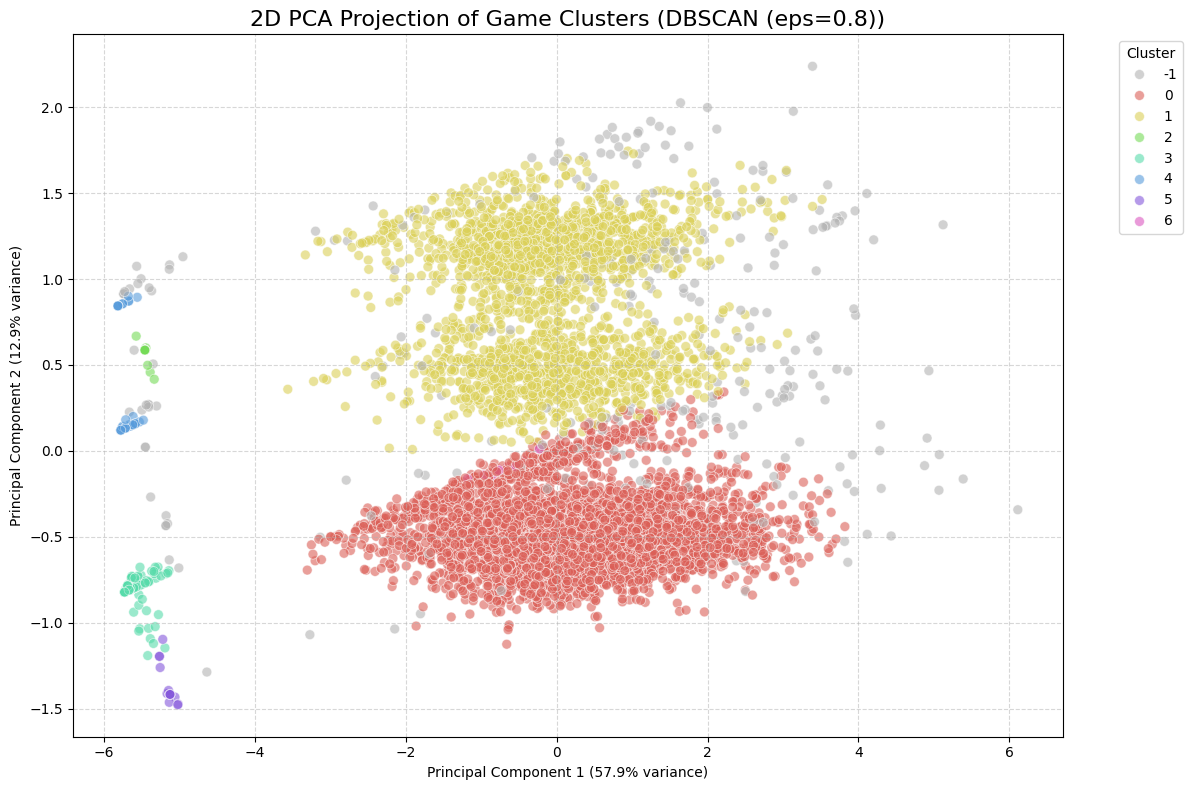

Total variance explained by 2 components: 70.86%


In [124]:
plot_pca_clusters(X_scaled, labels_dbscan,f"DBSCAN (eps={eps_value})")

/tmp/ipykernel_10670/1117527355.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sil, x='Silhouette', y='Algorithm', ax=axes[0, 0], palette=palette, edgecolor='black')
/tmp/ipykernel_10670/1117527355.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_time, x='Time (s)', y='Algorithm', ax=axes[0, 1], palette="viridis", edgecolor='black')
/tmp/ipykernel_10670/1117527355.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_mem, x='Memory (MB)', y='Algorithm', ax=axes[1, 0], palette="crest", edgecolor='black')
/tmp/i

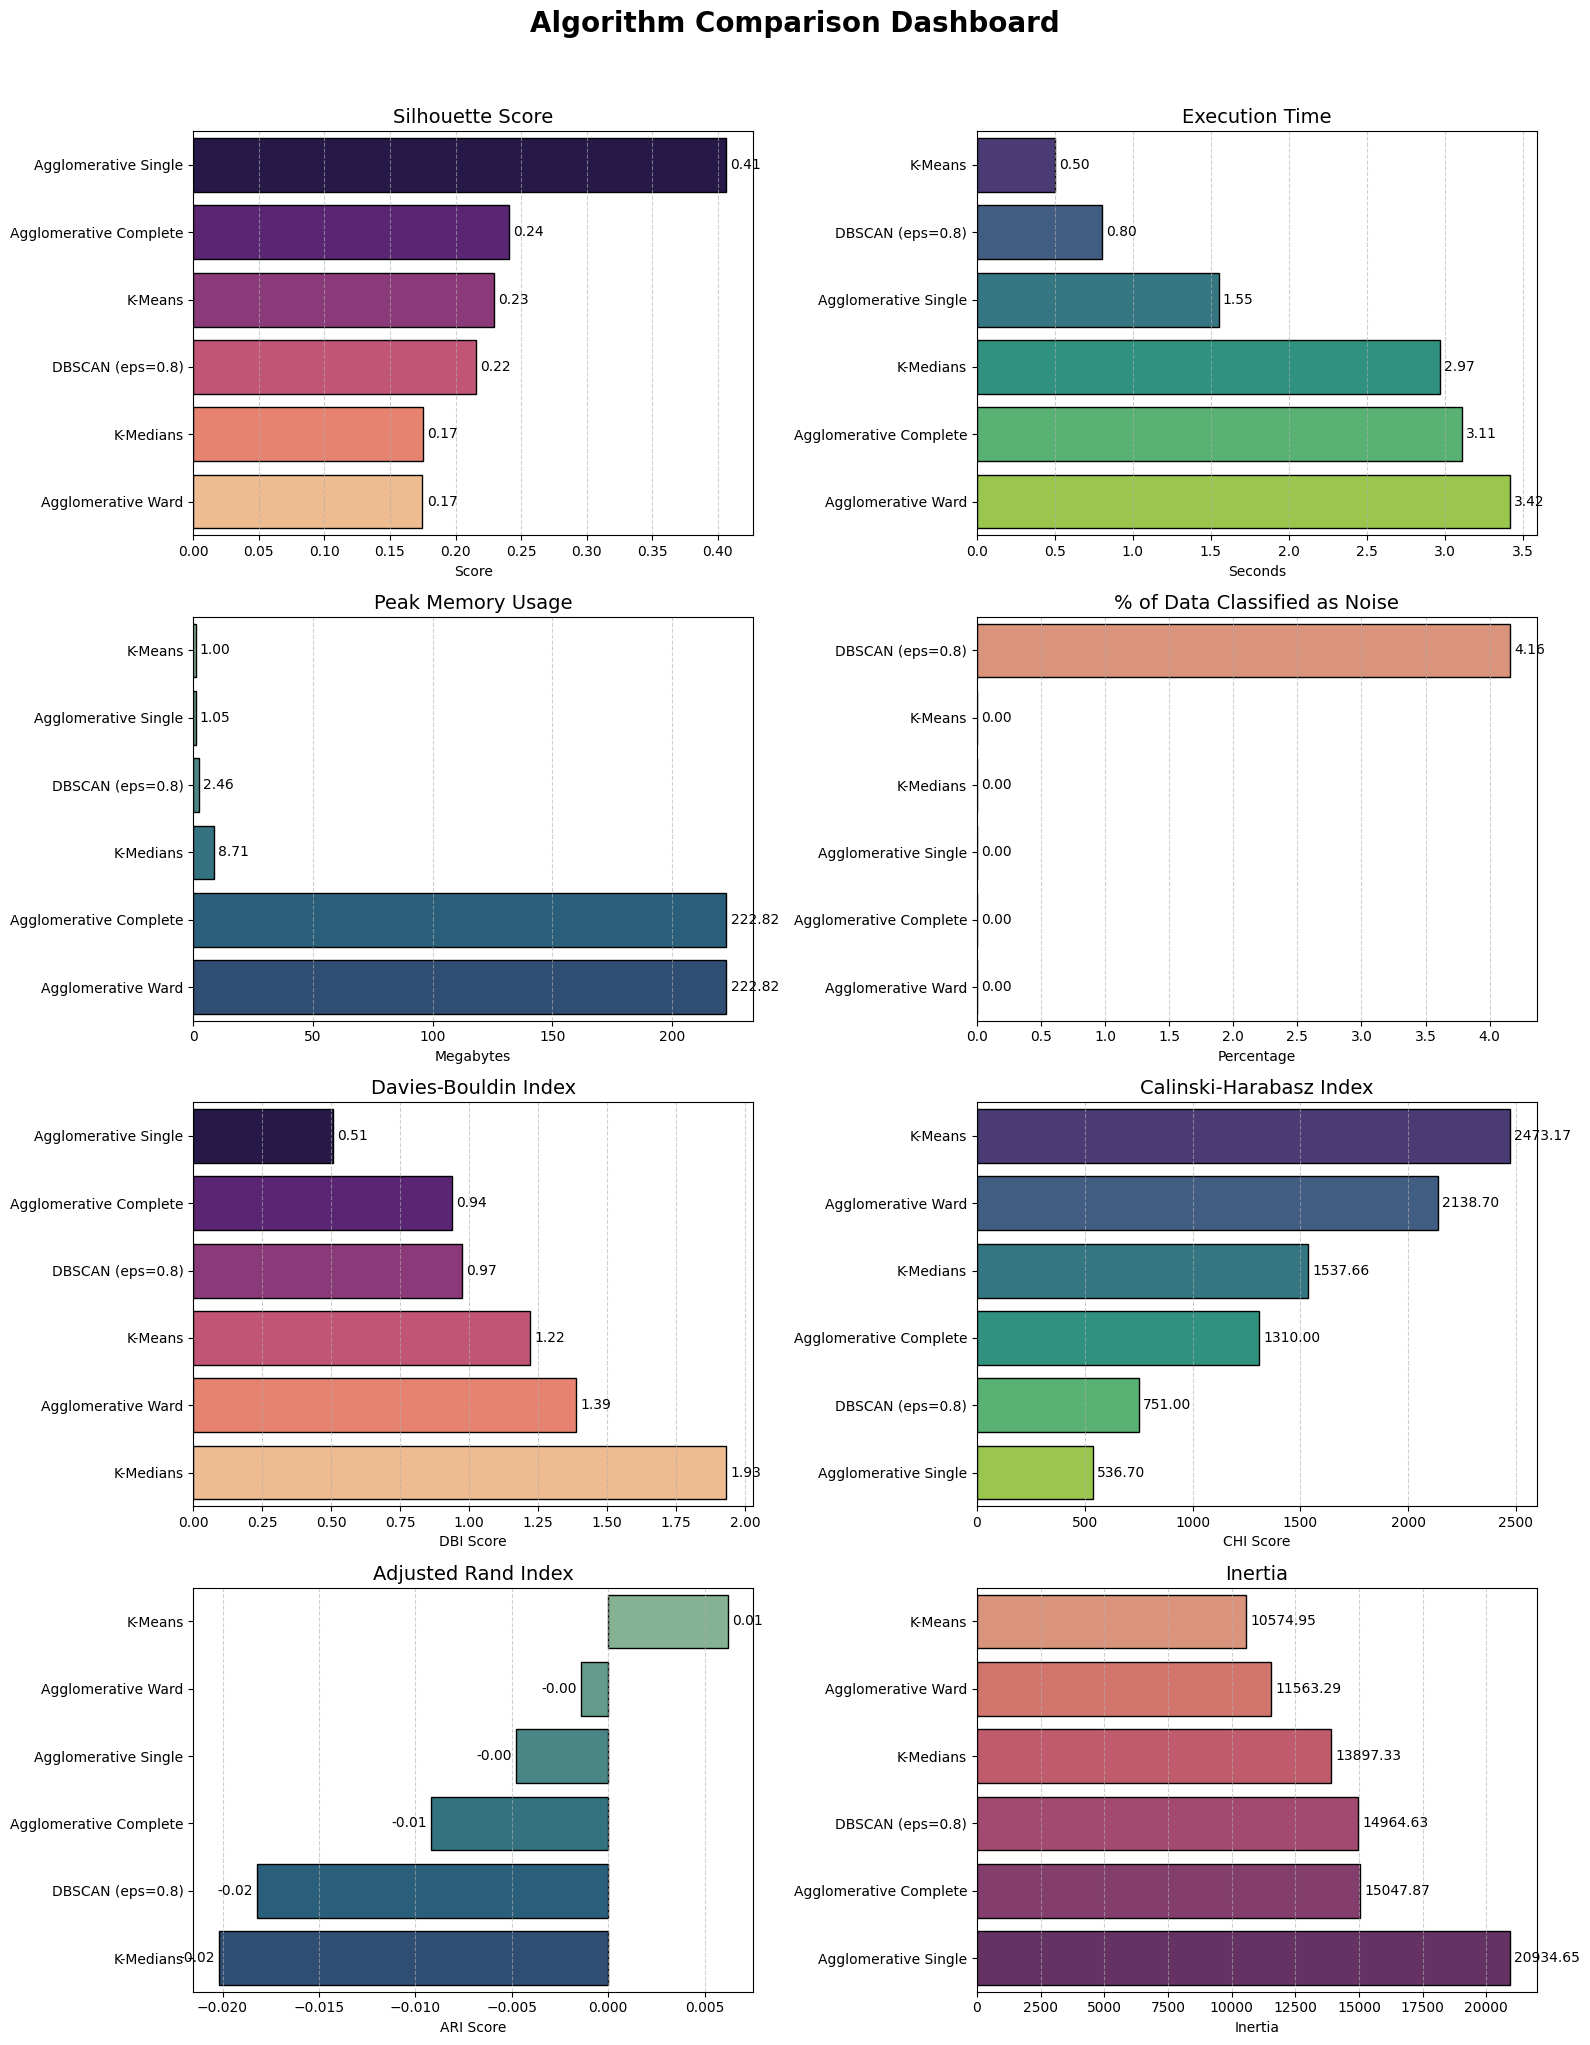


### Final Results Table ###
             Algorithm  N of clusters  Silhouette    DBI       CHI     ARI  Noise %  Inertia  Time (s)  Memory (MB)
               K-Means              6      0.2294 1.2210 2473.1708  0.0062     0.00 10574.95      0.50         1.00
             K-Medians              6      0.1749 1.9327 1537.6635 -0.0202     0.00 13897.33      2.97         8.71
  Agglomerative Single              6      0.4066 0.5053  536.7025 -0.0048     0.00 20934.65      1.55         1.05
Agglomerative Complete              6      0.2409 0.9365 1309.9958 -0.0092     0.00 15047.87      3.11       222.82
    Agglomerative Ward              6      0.1748 1.3875 2138.7038 -0.0014     0.00 11563.29      3.42       222.82
      DBSCAN (eps=0.8)              7      0.2159 0.9732  750.9997 -0.0182     4.16 14964.63      0.80         2.46


In [136]:
df_res = pd.DataFrame(results)
df_plot = df_res.drop_duplicates(subset=['Algorithm'], keep='last').copy()

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
fig.suptitle('Algorithm Comparison Dashboard', fontsize=20, fontweight='bold', y=1.02)
palette = sns.color_palette("magma", len(df_plot))

df_sil = df_plot.sort_values(by='Silhouette', ascending=False)
sns.barplot(data=df_sil, x='Silhouette', y='Algorithm', ax=axes[0, 0], palette=palette, edgecolor='black')
axes[0, 0].set_title('Silhouette Score', fontsize=14)
axes[0, 0].set_xlabel('Score')
axes[0, 0].set_ylabel('')

df_time = df_plot.sort_values(by='Time (s)', ascending=True)
sns.barplot(data=df_time, x='Time (s)', y='Algorithm', ax=axes[0, 1], palette="viridis", edgecolor='black')
axes[0, 1].set_title('Execution Time', fontsize=14)
axes[0, 1].set_xlabel('Seconds')
axes[0, 1].set_ylabel('')

df_mem = df_plot.sort_values(by='Memory (MB)', ascending=True)
sns.barplot(data=df_mem, x='Memory (MB)', y='Algorithm', ax=axes[1, 0], palette="crest", edgecolor='black')
axes[1, 0].set_title('Peak Memory Usage', fontsize=14)
axes[1, 0].set_xlabel('Megabytes')
axes[1, 0].set_ylabel('')

df_noise = df_plot.sort_values(by='Noise %', ascending=False)
sns.barplot(data=df_noise, x='Noise %', y='Algorithm', ax=axes[1, 1], palette="flare", edgecolor='black')
axes[1, 1].set_title('% of Data Classified as Noise', fontsize=14)
axes[1, 1].set_xlabel('Percentage')
axes[1, 1].set_ylabel('')

df_dbi = df_plot.sort_values(by='DBI', ascending=True)
sns.barplot(data=df_dbi, x='DBI', y='Algorithm', ax=axes[2, 0], palette=palette, edgecolor='black')
axes[2, 0].set_title('Davies-Bouldin Index', fontsize=14)
axes[2, 0].set_xlabel('DBI Score')
axes[2, 0].set_ylabel('')

df_chi = df_plot.sort_values(by='CHI', ascending=False)
sns.barplot(data=df_chi, x='CHI', y='Algorithm', ax=axes[2, 1], palette="viridis", edgecolor='black')
axes[2, 1].set_title('Calinski-Harabasz Index', fontsize=14)
axes[2, 1].set_xlabel('CHI Score')
axes[2, 1].set_ylabel('')

df_ari = df_plot.sort_values(by='ARI', ascending=False)
sns.barplot(data=df_ari, x='ARI', y='Algorithm', ax=axes[3, 0], palette="crest", edgecolor='black')
axes[3, 0].set_title('Adjusted Rand Index', fontsize=14)
axes[3, 0].set_xlabel('ARI Score')
axes[3, 0].set_ylabel('')

df_inertia = df_plot.sort_values(by='Inertia', ascending=True)
sns.barplot(data=df_inertia, x='Inertia', y='Algorithm', ax=axes[3, 1], palette="flare", edgecolor='black')
axes[3, 1].set_title('Inertia', fontsize=14)
axes[3, 1].set_xlabel('Inertia')
axes[3, 1].set_ylabel('')

for ax in axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)
    ax.grid(True, axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("\n### Final Results Table ###")
print(df_plot.dropna(axis=1, how='all').to_string(index=False))

# <a id="results"></a>
# Висновки

За результатами виконання роботи можна зробити такі висновки:


*   K-means показав найкращий результат для датасету за сукупністю показників інерції, часу виконання, використаної пам'яті.
*   DBSCAN дозволив змінити перспективу, шляхом виділення викидів в категорію шуму, в яку переважно потрапили дуже успішні ігри, які дійсно важко порівнювати з основною масою екземплярів.
*   З Агломераційний алгоритмів, найкращий результат показав спосіб Ward, проте він є найбільшим споживником пам'яті та найповільніший серед усіх розглянутих алгоритмів. Single link показує високі показники з деяких параметрів, проте в результаті піддався chaining'у та утворив один непрактичний надкластер.
*   Визначений показник для ARI, заданий у вигляді категорій відгуків до гри, показав малу ступінь кореляції для усіх розглянутих алгоритмів, з чого можна зробити висновок, що суспільне прийняття гри не залежить від її ціни, онлайну чи інших числових показників.


